<a href="https://colab.research.google.com/github/sensiboi/Digital-Marketing-Campaign-Performance-Analysis-and-ROI-Optimization/blob/main/Digital_Marketing_Campaign_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Digital Marketing Campaign Performance Analysis and ROI Optimization**

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

Import Dataset

In [2]:
df= pd.read_csv("digital_marketing_campaign_dataset.csv")
df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


Data Cleaning and preparation

In [3]:
#handle missing values
df.fillna(0, inplace=True)
#Remove duplicates
df.drop_duplicates(inplace=True)

Core Numerical KPIs

In [5]:
numeric_kpis = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_kpis

['CustomerID',
 'Age',
 'Income',
 'AdSpend',
 'ClickThroughRate',
 'ConversionRate',
 'WebsiteVisits',
 'PagesPerVisit',
 'TimeOnSite',
 'SocialShares',
 'EmailOpens',
 'EmailClicks',
 'PreviousPurchases',
 'LoyaltyPoints',
 'Conversion']

KPI Summary Table

In [7]:
kpi_summary = pd.DataFrame({
    'Mean': df[numeric_kpis].mean(),
    'Median': df[numeric_kpis].median(),
    'Std_Dev': df[numeric_kpis].std(),
    'Min': df[numeric_kpis].min(),
    'Max': df[numeric_kpis].max()
})
kpi_summary

,Mean,Median,Std_Dev,Min,Max
CustomerID,11999.500000,11999.500000,2309.545410,8000.000000,15999.000000
Age,43.625500,43.000000,14.902785,18.000000,69.000000
Income,84664.196750,84926.500000,37580.387945,20014.000000,149986.000000
AdSpend,5000.944830,5013.440044,2838.038153,100.054813,9997.914781
ClickThroughRate,0.154829,0.154505,0.084007,0.010005,0.299968
ConversionRate,0.104389,0.104046,0.054878,0.010018,0.199995
WebsiteVisits,24.751625,25.000000,14.312269,0.000000,49.000000
PagesPerVisit,5.549299,5.534257,2.607358,1.000428,9.999055
TimeOnSite,7.727718,7.682956,4.228218,0.501669,14.995311
SocialShares,49.799750,50.000000,28.901165,0.000000,99.000000


Visualisation Analytics [Performance Distribution]

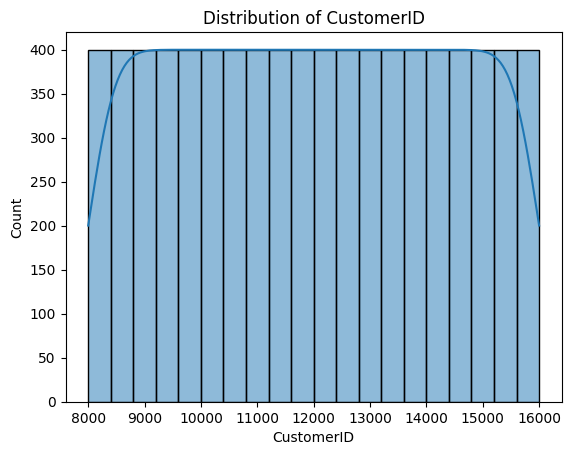

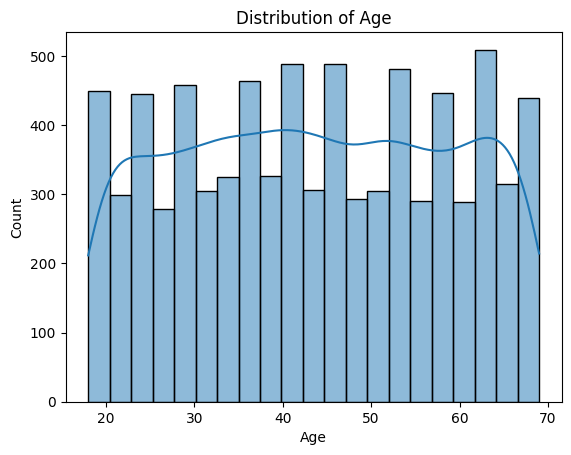

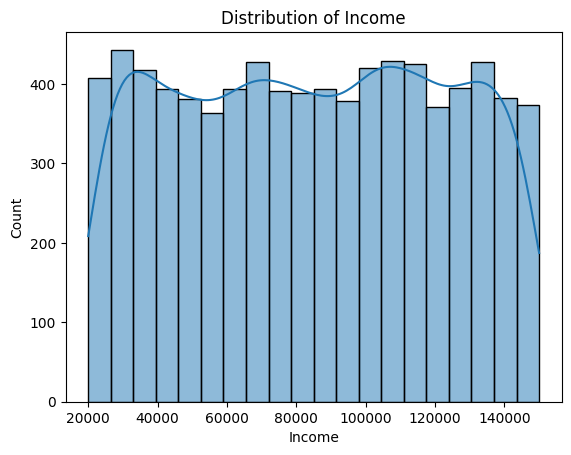

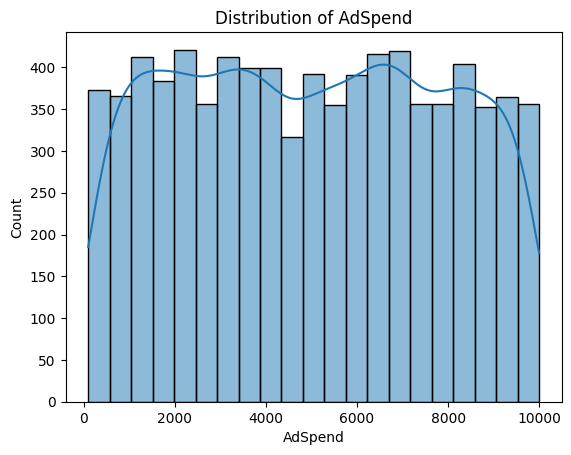

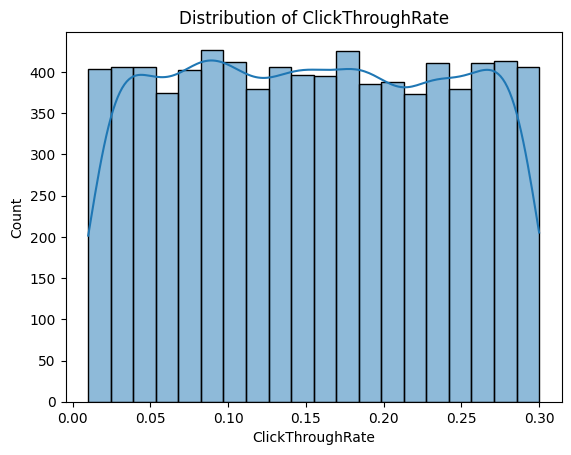

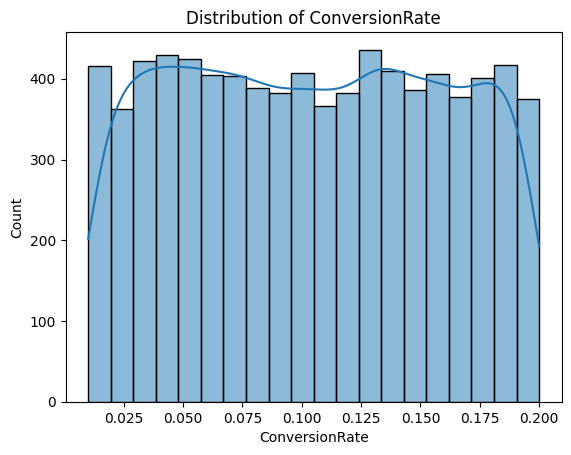

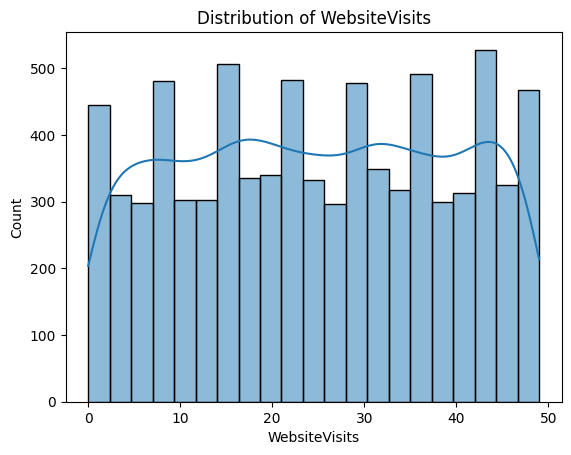

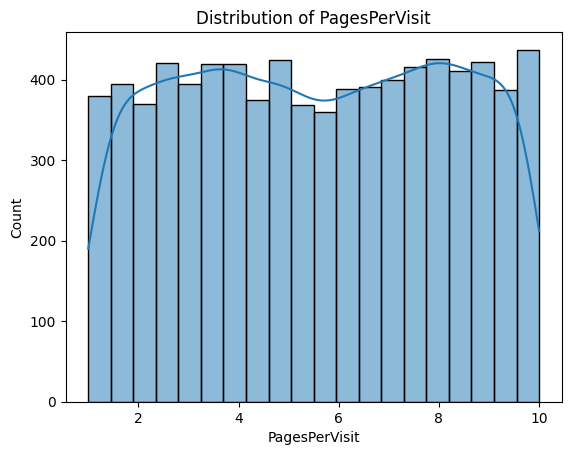

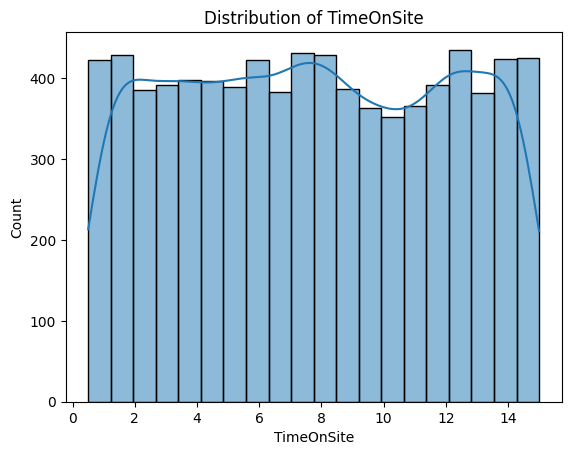

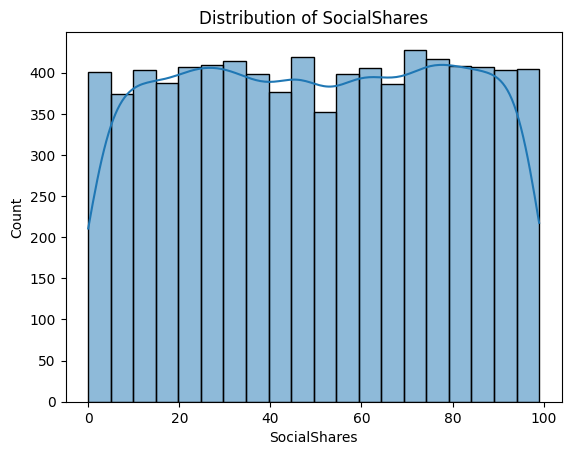

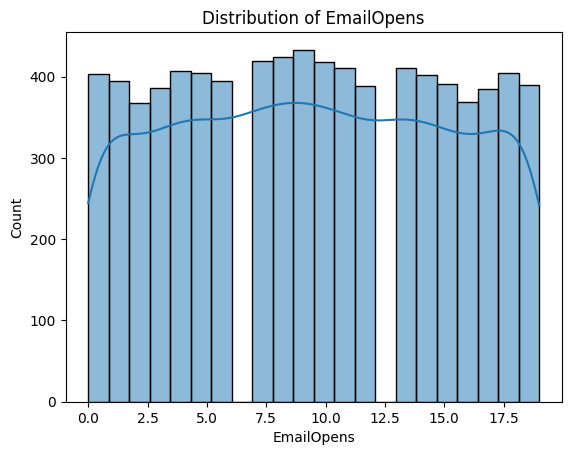

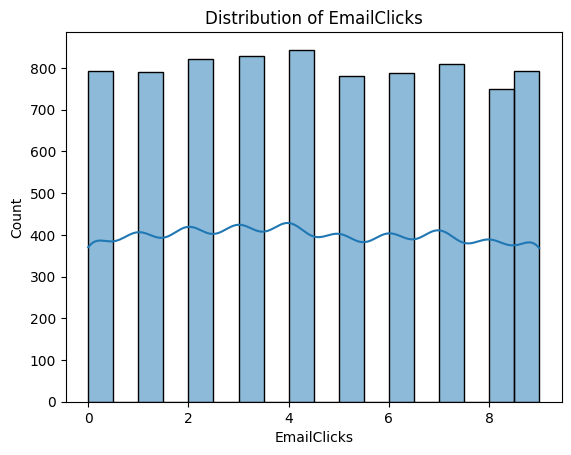

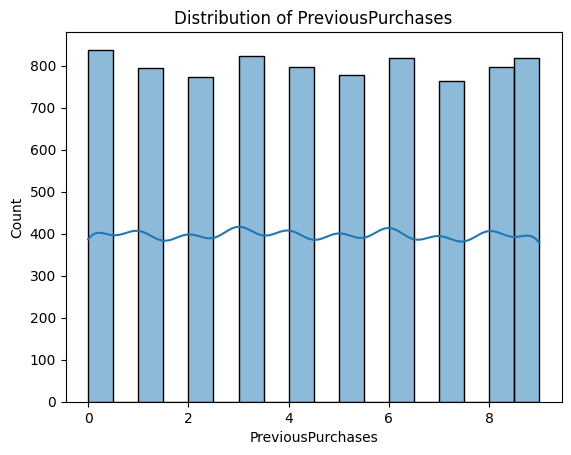

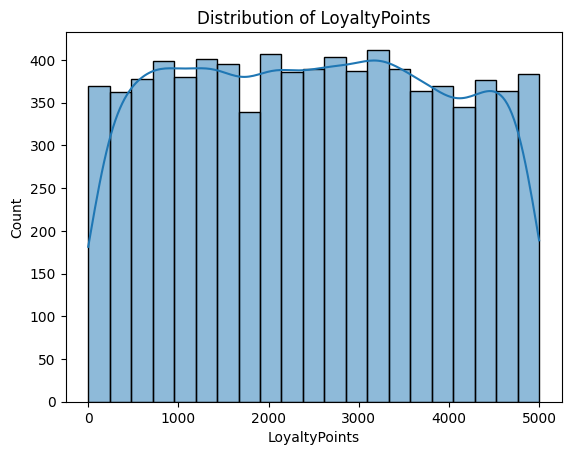

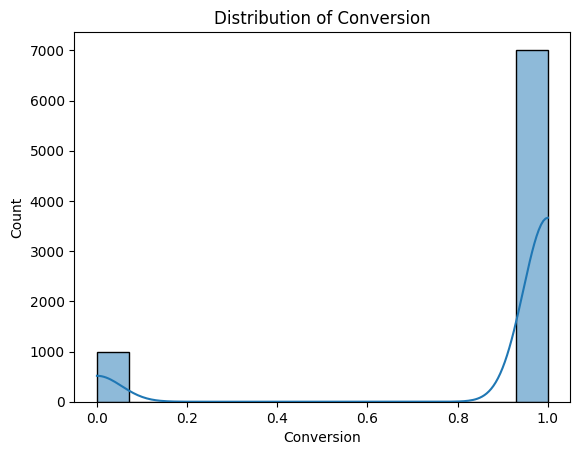

In [8]:
for col in numeric_kpis:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# **A/B Testing**

Test Simulation

In [10]:
np.random.seed(42)
df['AB_Group'] = np.random.choice(['A', 'B'], size=len(df))

Generic A/B Test Function

In [13]:
def run_ab_test(data, metric):
    A = data[data['AB_Group'] == 'A'][metric]
    B = data[data['AB_Group'] == 'B'][metric]
    stat, p_value = ttest_ind(A, B, nan_policy='omit', equal_var=False)
    return {
        'Metric': metric,
        'A_Mean': A.mean(),
        'B_Mean': B.mean(),
        'P_Value': p_value,
        'Winner': 'A' if A.mean() > B.mean() else 'B',
        'Significant': p_value < 0.05
    }

Run A/B Test for all KPIs

In [14]:
ab_results = pd.DataFrame([run_ab_test(df, kpi) for kpi in numeric_kpis])
ab_results

,Metric,A_Mean,B_Mean,P_Value,Winner,Significant
0,CustomerID,12003.379259,11995.579794,0.879968,A,False
1,Age,43.769460,43.480020,0.385109,A,False
2,Income,84703.011440,84624.972355,0.926013,A,False
3,AdSpend,5028.831754,4972.763548,0.376996,A,False
4,ClickThroughRate,0.155582,0.154067,0.420034,A,False
5,ConversionRate,0.104677,0.104098,0.637115,A,False
6,WebsiteVisits,25.035563,24.464690,0.074470,A,False
7,PagesPerVisit,5.504955,5.594111,0.126223,B,False
8,TimeOnSite,7.733863,7.721509,0.896050,A,False
9,SocialShares,49.559065,50.042976,0.454040,B,False


A/B Test Comparison

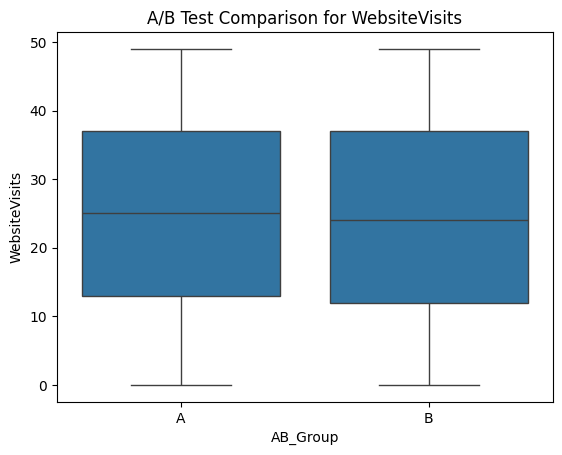

In [15]:
best_metric = ab_results.sort_values('P_Value').iloc[0]['Metric']
plt.figure()
sns.boxplot(data=df, x='AB_Group', y=best_metric)
plt.title(f"A/B Test Comparison for {best_metric}")
plt.show()

Auto Business Insight Generation

In [16]:
for _, row in ab_results.iterrows():
    if row['Significant']:
        print(
            f"Variant {row['Winner']} performed better for {row['Metric']} "
            f"with average value {max(row['A_Mean'], row['B_Mean']):.2f} "
            f"(p-value = {row['P_Value']:.4f})."
        )
    else:
        print(
            f"No statistically significant difference observed for {row['Metric']} "
            f"(p-value = {row['P_Value']:.4f})."
        )

No statistically significant difference observed for CustomerID (p-value = 0.8800).
No statistically significant difference observed for Age (p-value = 0.3851).
No statistically significant difference observed for Income (p-value = 0.9260).
No statistically significant difference observed for AdSpend (p-value = 0.3770).
No statistically significant difference observed for ClickThroughRate (p-value = 0.4200).
No statistically significant difference observed for ConversionRate (p-value = 0.6371).
No statistically significant difference observed for WebsiteVisits (p-value = 0.0745).
No statistically significant difference observed for PagesPerVisit (p-value = 0.1262).
No statistically significant difference observed for TimeOnSite (p-value = 0.8961).
No statistically significant difference observed for SocialShares (p-value = 0.4540).
No statistically significant difference observed for EmailOpens (p-value = 0.3210).
No statistically significant difference observed for EmailClicks (p-valu

KPI Scorecard

In [17]:
scorecard = ab_results[['Metric', 'A_Mean', 'B_Mean', 'Winner', 'Significant']]
scorecard

,Metric,A_Mean,B_Mean,Winner,Significant
0,CustomerID,12003.379259,11995.579794,A,False
1,Age,43.769460,43.480020,A,False
2,Income,84703.011440,84624.972355,A,False
3,AdSpend,5028.831754,4972.763548,A,False
4,ClickThroughRate,0.155582,0.154067,A,False
5,ConversionRate,0.104677,0.104098,A,False
6,WebsiteVisits,25.035563,24.464690,A,False
7,PagesPerVisit,5.504955,5.594111,B,False
8,TimeOnSite,7.733863,7.721509,A,False
9,SocialShares,49.559065,50.042976,B,False
